John Lopes 300319245 and Taha Riyaan 300280252

Group 28

Worksplit: 
John: Regression Empirical Study with Linear Regression
Taha: Classification Empirical Study with Decision Trees

In [127]:
import seaborn as sns
import matplotlib.pyplot as plt
import kagglehub
import pandas as pd
import numpy as np
from sklearn.neighbors import LocalOutlierFactor
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from sklearn.metrics import mean_squared_error, mean_absolute_error

In [128]:
path = kagglehub.dataset_download(
    "nehalbirla/vehicle-dataset-from-cardekho"
)
ogdf = pd.read_csv(f"{path}/CAR DETAILS FROM CAR DEKHO.csv")
df = ogdf.copy()
third = int(len(df)/3)
#dff is for part f, the first third has been removed as it is the test data
dff = df.iloc[third:].copy()
dffValidation = df.iloc[:third].copy()
#df.head()

# Dataset 1 - Vehicle dataset
by John Lopes

## Description

"This dataset contains information about used cars.
This data can be used for a lot of purposes such as price prediction to exemplify the use of linear regression in Machine Learning."

key features:
1. name
2. year
3. selling_price
4. km_driven
5. fuel
6. seller_type
7. transmission
8. Owner

## Code

## a)

In [129]:
#wrong indices
indiciesMask = []

#look up
transmissionValues = ["Automatic", "Manual"]
transmissionInvalid = df.loc[~df["transmission"].isin(transmissionValues)].index.tolist()
indiciesMask.extend(transmissionInvalid)

fuelValues = ["Diesel", "Petrol", "CNG", "LPG", "Electric"]
fuelInvalid = df.loc[~df["fuel"].isin(fuelValues)].index.tolist()
indiciesMask.extend(fuelInvalid)

In [130]:
#presence
nullMask = df.isnull().any(axis=1)
emptyMask = (df == "").any(axis=1)

emptyRows = df[nullMask | emptyMask]
emptyIndices = emptyRows.index.tolist()
indiciesMask.extend(emptyIndices)

In [131]:
df = df.drop(indiciesMask, axis="index")

## b)

In [132]:
#did not encode the name column due to unique values
dfEncoded = pd.get_dummies(df.copy(), columns=["fuel", "transmission", "owner", "seller_type"], drop_first=False,dtype=int)
dfAggregate = dfEncoded.copy()
dfEncoded.head()
#print(df["fuel"])
#print(dfEncoded["fuel_Diesel"])

,name,year,selling_price,km_driven,fuel_CNG,fuel_Diesel,fuel_Electric,fuel_LPG,fuel_Petrol,transmission_Automatic,transmission_Manual,owner_First Owner,owner_Fourth & Above Owner,owner_Second Owner,owner_Test Drive Car,owner_Third Owner,seller_type_Dealer,seller_type_Individual,seller_type_Trustmark Dealer
0,Maruti 800 AC,2007,60000,70000,0,0,0,0,1,0,1,1,0,0,0,0,0,1,0
1,Maruti Wagon R LXI Minor,2007,135000,50000,0,0,0,0,1,0,1,1,0,0,0,0,0,1,0
2,Hyundai Verna 1.6 SX,2012,600000,100000,0,1,0,0,0,0,1,1,0,0,0,0,0,1,0
3,Datsun RediGO T Option,2017,250000,46000,0,0,0,0,1,0,1,1,0,0,0,0,0,1,0
4,Honda Amaze VX i-DTEC,2014,450000,141000,0,1,0,0,0,0,1,0,0,1,0,0,0,1,0


## c)

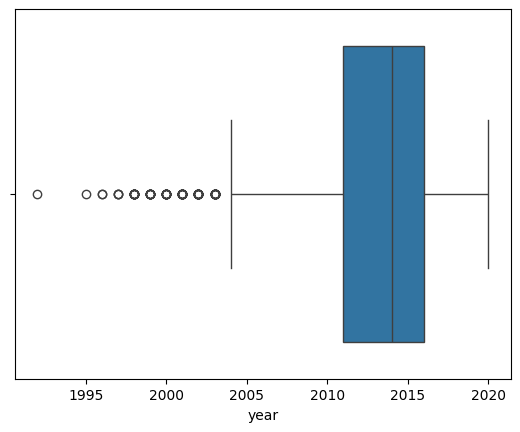

In [133]:
yearPlot = sns.boxplot(df,x="year")

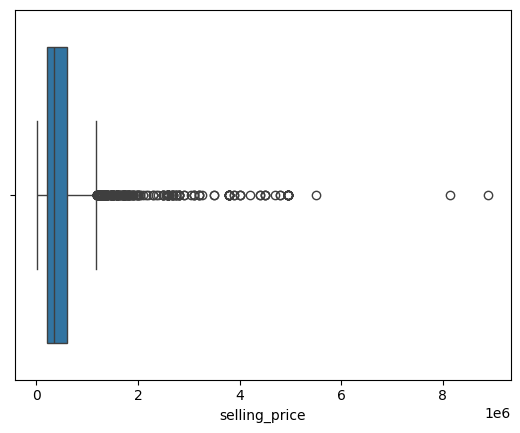

In [134]:
sellingPrice = sns.boxplot(df,x="selling_price")

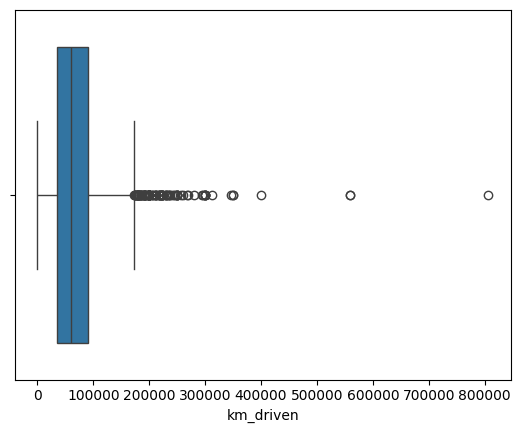

In [135]:
kmDriven = sns.boxplot(df,x="km_driven")

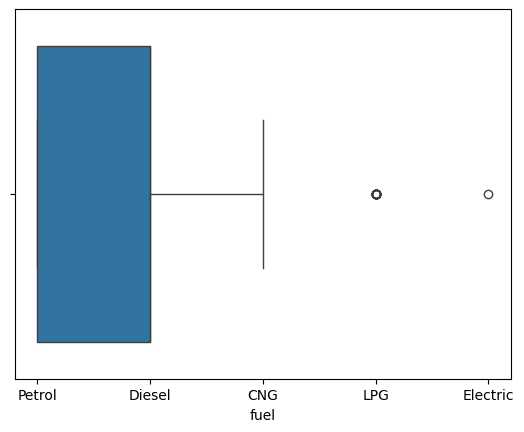

In [136]:
fuelPlot = sns.boxplot(df,x="fuel")

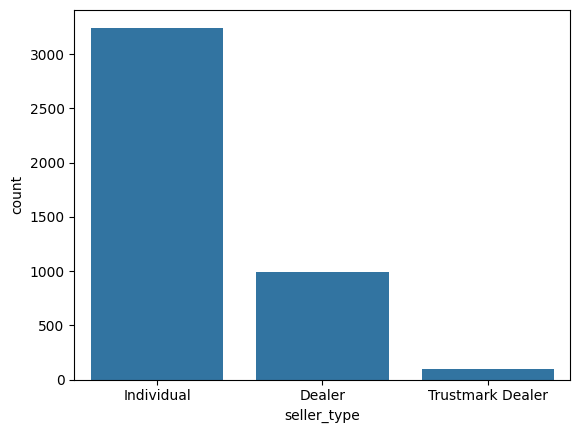

In [137]:
sellerPlot = sns.countplot(df,x="seller_type")

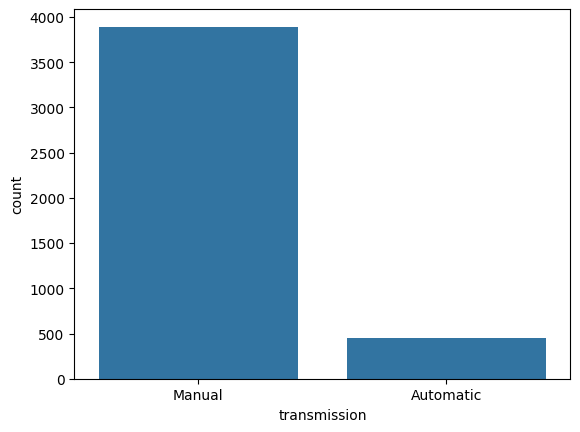

In [138]:
transmissionPlot = sns.countplot(df,x="transmission")

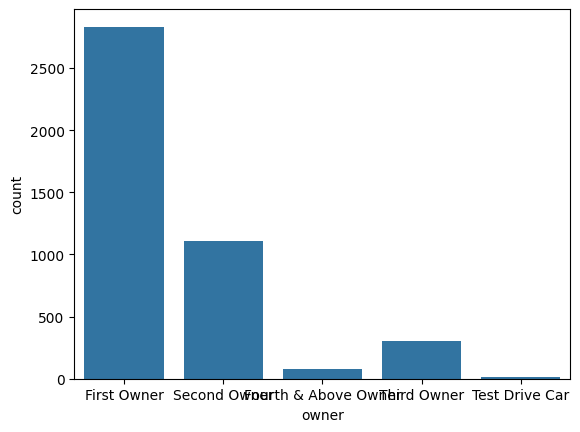

In [139]:
ownerPlot = sns.countplot(df,x="owner")

In [140]:
lof = LocalOutlierFactor(n_neighbors=20, contamination=0.05)

cols = [col for col in dfEncoded.columns if col not in ["name"]]
dfEncoded["lof_label"] = lof.fit_predict(dfEncoded[cols])

dfEncoded[dfEncoded["lof_label"] == -1].head()

,name,year,selling_price,km_driven,fuel_CNG,fuel_Diesel,fuel_Electric,fuel_LPG,fuel_Petrol,transmission_Automatic,transmission_Manual,owner_First Owner,owner_Fourth & Above Owner,owner_Second Owner,owner_Test Drive Car,owner_Third Owner,seller_type_Dealer,seller_type_Individual,seller_type_Trustmark Dealer,lof_label
32,Audi Q5 2.0 TDI,2011,1190000,175900,0,1,0,0,0,1,0,1,0,0,0,0,1,0,0,-1
56,Hyundai i20 Sportz 1.4 CRDi,2018,750000,29000,0,1,0,0,0,0,1,1,0,0,0,0,1,0,0,-1
57,Maruti Omni Maruti Omni MPI STD BSIII 5-STR W/...,2018,310000,28000,0,0,0,0,1,0,1,1,0,0,0,0,1,0,0,-1
69,Chevrolet Tavera Neo LS B3 - 7(C) seats BSIII,2010,280000,350000,0,1,0,0,0,0,1,0,0,1,0,0,0,1,0,-1
70,Toyota Corolla Altis Diesel D4DG,2011,350000,230000,0,1,0,0,0,0,1,1,0,0,0,0,0,1,0,-1


In [141]:
print(dfEncoded[dfEncoded["lof_label"]==-1])
#removing outliers
dfEncoded = dfEncoded[dfEncoded["lof_label"]!=-1]
print(dfEncoded[dfEncoded["lof_label"]==-1])
# dfEncoded.head()

                                                   name  year  selling_price  \
32                                      Audi Q5 2.0 TDI  2011        1190000   
56                          Hyundai i20 Sportz 1.4 CRDi  2018         750000   
57    Maruti Omni Maruti Omni MPI STD BSIII 5-STR W/...  2018         310000   
69        Chevrolet Tavera Neo LS B3 - 7(C) seats BSIII  2010         280000   
70                     Toyota Corolla Altis Diesel D4DG  2011         350000   
...                                                 ...   ...            ...   
4282                            Maruti Wagon R LX Minor  2013         290000   
4294                          Mahindra XUV500 AT W8 FWD  2015         740000   
4326                                 Honda City 1.5 GXI  2005          65000   
4331               Ford EcoSport 1.5 TDCi Titanium BSIV  2015         530000   
4334       Toyota Innova 2.5 VX (Diesel) 8 Seater BS IV  2012         600000   

      km_driven  fuel_CNG  fuel_Diesel 

## d)

In [142]:
dfEncoded.sort_values(by="year", ascending=True)
x = dfEncoded[["year", "km_driven", "fuel_CNG", "fuel_Diesel", "fuel_Electric", "fuel_LPG", "fuel_Petrol", "transmission_Manual", "transmission_Automatic","owner_First Owner", "owner_Fourth & Above Owner", "owner_Second Owner","owner_Third Owner" ,"owner_Test Drive Car", "seller_type_Individual", "seller_type_Trustmark Dealer", "seller_type_Dealer"]]
y = dfEncoded["selling_price"]

model = LinearRegression()

scores = cross_val_score(
    model,
    x,
    y,
    scoring="r2", 
    cv=4,
)

print("R� per fold:", scores)
print("Mean R�:", scores.mean())
print("Std R�:", scores.std())

R� per fold: [0.47769129 0.47670804 0.44982127 0.4116719 ]
Mean R�: 0.4539731272922351
Std R�: 0.026861026925487308


## e)

In [143]:
dfAggregate["transmission_Manual_fuel_Diesel"] = (dfAggregate["transmission_Manual"] & dfAggregate["fuel_Diesel"]).astype(int)

dfAggregate[["transmission_Manual", "fuel_Diesel", "transmission_Manual_fuel_Diesel"]].head()

,transmission_Manual,fuel_Diesel,transmission_Manual_fuel_Diesel
0,1,0,0
1,1,0,0
2,1,1,1
3,1,0,0
4,1,1,1


In [144]:
for idx, row in dfAggregate.iterrows():
    dfAggregate['car_age'] = 2026 - dfAggregate['year']
dfAggregate[["year", "car_age"]].head()

,year,car_age
0,2007,19
1,2007,19
2,2012,14
3,2017,9
4,2014,12


## f) 

In [ ]:
#removed outliers
dffEncoded = pd.get_dummies(dff.copy(), columns=["fuel", "transmission", "owner", "seller_type"], drop_first=False, dtype=int)
lof = LocalOutlierFactor(n_neighbors=20, contamination=0.05)
cols = [col for col in dffEncoded.columns if col not in ["name"]]
dffEncoded["lof_label"] = lof.fit_predict(dffEncoded[cols])
dffEncoded = dffEncoded[dffEncoded["lof_label"]!=-1]

x = dffEncoded[["year", "km_driven", "fuel_CNG", "fuel_Diesel", "fuel_Electric", "fuel_LPG", "fuel_Petrol", "transmission_Manual", "transmission_Automatic","owner_First Owner", "owner_Fourth & Above Owner", "owner_Second Owner","owner_Third Owner" ,"owner_Test Drive Car", "seller_type_Individual", "seller_type_Trustmark Dealer", "seller_type_Dealer"]]
y = dffEncoded["selling_price"]

modelo = LinearRegression()

scores = cross_val_score(
    modelo,
    x,
    y,
    scoring="r2", 
    cv=4,
)

print("R� per fold:", scores)
print("Mean R�:", scores.mean())
print("Std R�:", scores.std())

R� per fold: [0.50193982 0.46280721 0.42100563 0.44181631]
Mean R�: 0.4568922454191212
Std R�: 0.029914058502177602


In [146]:
#aggregate features
dfffEncoded = pd.get_dummies(dff.copy(), columns=["fuel", "transmission", "owner", "seller_type"], drop_first=False, dtype=int)

for idx, row in dfffEncoded.iterrows():
    dfffEncoded["car_age"] = 2026 - dfffEncoded["year"]


x = dfffEncoded[["year", "km_driven", "fuel_CNG", "fuel_Diesel", "fuel_Electric", "fuel_LPG", "fuel_Petrol", "transmission_Manual", "transmission_Automatic","owner_First Owner", "owner_Fourth & Above Owner", "owner_Second Owner","owner_Third Owner" ,"owner_Test Drive Car", "seller_type_Individual", "seller_type_Trustmark Dealer", "seller_type_Dealer", "car_age"]]
y = dfffEncoded["selling_price"]

modela = LinearRegression()

scores = cross_val_score(
    modela,
    x,
    y,
    scoring="r2", 
    cv=4,
)

print("R� per fold:", scores)
print("Mean R�:", scores.mean())
print("Std R�:", scores.std())

R� per fold: [0.47831266 0.45900001 0.32762145 0.35942601]
Mean R�: 0.4060900335746852
Std R�: 0.06393438690433553


In [147]:
#aggregate features & removed outliers 
dffffEncoded = pd.get_dummies(dff.copy(), columns=["fuel", "transmission", "owner", "seller_type"], drop_first=False, dtype=int)

for idx, row in dffffEncoded.iterrows():
    dffffEncoded["car_age"] = 2026 - dffffEncoded["year"]

lof = LocalOutlierFactor(n_neighbors=20, contamination=0.05)
cols = [col for col in dffffEncoded.columns if col not in ["name"]]
dffffEncoded["lof_label"] = lof.fit_predict(dffffEncoded[cols])
dffffEncoded = dffffEncoded[dffffEncoded["lof_label"]!=-1]

x = dffffEncoded[["year", "km_driven", "fuel_CNG", "fuel_Diesel", "fuel_Electric", "fuel_LPG", "fuel_Petrol", "transmission_Manual", "transmission_Automatic","owner_First Owner", "owner_Fourth & Above Owner", "owner_Second Owner","owner_Third Owner" ,"owner_Test Drive Car", "seller_type_Individual", "seller_type_Trustmark Dealer", "seller_type_Dealer", "car_age"]]
y = dffffEncoded["selling_price"]

modelao = LinearRegression()

scores = cross_val_score(
    modelao,
    x,
    y,
    scoring="r2", 
    cv=4,
)

print("R� per fold:", scores)
print("Mean R�:", scores.mean())
print("Std R�:", scores.std())

R� per fold: [0.50193982 0.46280721 0.42100563 0.44181631]
Mean R�: 0.4568922454191211
Std R�: 0.02991405850217614


In [148]:
#removed outliers had the highest R� test score

dffEncoded = pd.get_dummies(dff.copy(), columns=["fuel", "transmission", "owner", "seller_type"], drop_first=False, dtype=int)
lof = LocalOutlierFactor(n_neighbors=20, contamination=0.05)
cols = [col for col in dffEncoded.columns if col not in ["name"]]
dffEncoded["lof_label"] = lof.fit_predict(dffEncoded[cols])
dffEncoded = dffEncoded[dffEncoded["lof_label"]!=-1]

x_train = dffEncoded[["year", "km_driven", "fuel_CNG", "fuel_Diesel", "fuel_Electric", "fuel_LPG", "fuel_Petrol", "transmission_Manual", "transmission_Automatic","owner_First Owner", "owner_Fourth & Above Owner", "owner_Second Owner","owner_Third Owner" ,"owner_Test Drive Car", "seller_type_Individual", "seller_type_Trustmark Dealer", "seller_type_Dealer"]]
y_train = dffEncoded["selling_price"]

model = LinearRegression().fit(x_train, y_train)

dffValidation = pd.get_dummies(dff.copy(), columns=["fuel", "transmission", "owner", "seller_type"], drop_first=False, dtype=int)
x_test = dffValidation[["year", "km_driven", "fuel_CNG", "fuel_Diesel", "fuel_Electric", "fuel_LPG", "fuel_Petrol", "transmission_Manual", "transmission_Automatic","owner_First Owner", "owner_Fourth & Above Owner", "owner_Second Owner","owner_Third Owner" ,"owner_Test Drive Car", "seller_type_Individual", "seller_type_Trustmark Dealer", "seller_type_Dealer"]]
y_test = dffValidation["selling_price"]
predictions = model.predict(x_test)
print("R� train:", model.score(x_train, y_train))
print("R� test :", model.score(x_test, y_test))

R� train: 0.4694392926805805
R� test : 0.4186574898853971


## g)

    a. There was an improvement from the base linear regression, R�: 0.4539731272922351, to the final linear regression that had outliers removed, Mean R�: 0.4568922454191212.
    b. Outlier detection in our data checks for outliers in each column, creating a new column called lof_label for marking outliers, and assigns outliers a label of -1. Rows that have been marked as outliers are then removed so that we can remove noise that could lead to lower accuracy in the model. Aggregation was used to create a new age column that tells the model how old a car is. this can be helpful for the model since creating new features that it can use provides an added context which leads to improved learning.
    c. The final test data was worse than our base linear regression, with an R� of 0.4186574898853971. This suggests that the model may have some overfitting issues. A potential way to fix this is by having a larger sized database.

## References

Localoutlierfactor. scikit. (n.d.). https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.LocalOutlierFactor.html 

GeeksforGeeks. (2025, July 11). Python: Linear regression using sklearn. https://www.geeksforgeeks.org/machine-learning/python-linear-regression-using-sklearn/ 

HelloMotors Corp. (2025, April 8). How mileage affects used car prices in Ontario - Hello Motors dealership: Auto Financing. Hello Motors Dealership | Auto Financing. https://hellomotors.ca/blog/how-mileage-affects-used-car-prices-in-ontario 

# Dataset 2

Name: Mushroom Classification

Author: UCI Machine Learning and Meg Risdal

Purpose: The dataset was built to classify mushrooms as edible or poisonous based on their physical characteristics.

Shape: The dataset consists of 8124 rows and 23 feature columns

Features:

| Feature Name | Description | Type |
|---|---|---|
| class | edible (e) or poisonous (p) | Categorical |
| cap-shape | Mushroom cap shape | Categorical |
| cap-surface | cap surfance texture| Categorical |
| cap-color | cap Colour | Categorical |
| bruises | if there are bruises | Categorical |
| odor | mushroom odor | Categorical |
| gill-attachment | how gills are attached | Categorical |
| gill-spacing | Space between gills | Categorical |
| gill-size | gill size | Categorical |
| gill-color | gill colour | Categorical |
| stalk-shape | shape of the stock | Categorical |
| stalk-root | stalk root type | Categorical |
| stalk-surface-above-ring | stalk surface texture above the ring | Categorical |
| stalk-surface-below-ring | stalk surface texture below the ring | Categorical |
| stalk-color-above-ring | Stalk color above the ring | Categorical |
| stalk-color-below-ring | Stalk color below the ring | Categorical |
| veil-type | Type of veil | Categorical |
| veil-color | veil colour | Categorical |
| ring-number | Number of rings | Categorical |
| ring-type | Type of ring | Categorical |
| spore-print-color | spore print colour | Categorical |
| population | Population density of mushroom| Categorical |
| habitat | Habitat where mushroom is found | Categorical |




In [ ]:
import matplotlib.pyplot as plt
import kagglehub
import pandas as pd
from pandas import DataFrame
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report
from sklearn.model_selection import cross_val_score
from sklearn.neighbors import LocalOutlierFactor
from sklearn.tree import DecisionTreeClassifier
import math
from sklearn.model_selection import KFold
from sklearn.metrics import f1_score


In [52]:
def kfold(dt, X_train_val, y_train_val):
    kf = KFold(n_splits=4, shuffle=True, random_state=42)
    scores_list = []

    for train_i, val_i in kf.split(X_train_val):
        X_train = X_train_val.iloc[train_i]
        X_val = X_train_val.iloc[val_i]
        y_train = y_train_val.iloc[train_i]
        y_val = y_train_val.iloc[val_i]

        dt.fit(X_train, y_train)

        y_pred = dt.predict(X_val)
        scores_list.append(f1_score(y_val, y_pred))

    print(f'Mean F1: {sum(scores_list)/len(scores_list) * 100:.2f}')

In [38]:
# dataset 

np.random.seed(42)

DATASET_PATH = kagglehub.dataset_download(
    "uciml/mushroom-classification"
)

df = pd.read_csv(f"{DATASET_PATH}/mushrooms.csv")

print('Head:', df.head())

print(len(df))

Head:   class cap-shape cap-surface cap-color bruises odor gill-attachment  \
0     p         x           s         n       t    p               f   
1     e         x           s         y       t    a               f   
2     e         b           s         w       t    l               f   
3     p         x           y         w       t    p               f   
4     e         x           s         g       f    n               f   

  gill-spacing gill-size gill-color  ... stalk-surface-below-ring  \
0            c         n          k  ...                        s   
1            c         b          k  ...                        s   
2            c         b          n  ...                        s   
3            c         n          n  ...                        s   
4            w         b          k  ...                        s   

  stalk-color-above-ring stalk-color-below-ring veil-type veil-color  \
0                      w                      w         p          w   
1 

In [39]:
# dataset info
print('======Info======')
df.info()

print('======Desctiption======')
df.describe

======Info======
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8124 entries, 0 to 8123
Data columns (total 23 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   class                     8124 non-null   object
 1   cap-shape                 8124 non-null   object
 2   cap-surface               8124 non-null   object
 3   cap-color                 8124 non-null   object
 4   bruises                   8124 non-null   object
 5   odor                      8124 non-null   object
 6   gill-attachment           8124 non-null   object
 7   gill-spacing              8124 non-null   object
 8   gill-size                 8124 non-null   object
 9   gill-color                8124 non-null   object
 10  stalk-shape               8124 non-null   object
 11  stalk-root                8124 non-null   object
 12  stalk-surface-above-ring  8124 non-null   object
 13  stalk-surface-below-ring  8124 non-null   object
 14  stalk-c

<bound method NDFrame.describe of      class cap-shape cap-surface cap-color bruises odor gill-attachment  \
0        p         x           s         n       t    p               f   
1        e         x           s         y       t    a               f   
2        e         b           s         w       t    l               f   
3        p         x           y         w       t    p               f   
4        e         x           s         g       f    n               f   
...    ...       ...         ...       ...     ...  ...             ...   
8119     e         k           s         n       f    n               a   
8120     e         x           s         n       f    n               a   
8121     e         f           s         n       f    n               a   
8122     p         k           y         n       f    y               f   
8123     e         x           s         n       f    n               a   

     gill-spacing gill-size gill-color  ... stalk-surface-below-r

## A Cleaning the data

In [40]:
# validation

valid_values = {
    'class': {'e','p'},
    'cap-shape': {'b','c','x','f','k','s'},
    'cap-surface': {'f','g','y','s'},
    'cap-color': {'n','b','c','g','r','p','u','e','w','y'},
    'bruises': {'t','f'},
    'odor': {'a','l','c','y','f','m','n','p','s'},
    'gill-attachment': {'a','d','f','n'},
    'gill-spacing': {'c','w','d'},
    'gill-size': {'b','n'},
    'gill-color': {'k','n','b','h','g','r','o','p','u','e','w','y'},
    'stalk-shape': {'e','t'},
    'stalk-root': {'b','c','u','e','z','r','?'},
    'stalk-surface-above-ring': {'f','y','k','s'},
    'stalk-surface-below-ring': {'f','y','k','s'},
    'stalk-color-above-ring': {'n','b','c','g','o','p','e','w','y'},
    'stalk-color-below-ring': {'n','b','c','g','o','p','e','w','y'},
    'veil-type': {'p','u'},
    'veil-color': {'n','o','w','y'},
    'ring-number': {'n','o','t'},
    'ring-type': {'c','e','f','l','n','p','s','z'},
    'spore-print-color': {'k','n','b','h','r','o','u','w','y'},
    'population': {'a','c','n','s','v','y'},
    'habitat': {'g','l','m','p','u','w','d'}
}

# all values in the set are aligned with what is expected
print('===Invalid check===')
for column, valid in valid_values.items():
    invalid = set(df[column].unique()) - valid
    if invalid: 
        print(f'{column} has invalid: {invalid}')
    # else:
    #     print(f'{column} is good')

print('===Unique check===')
# check for columns with constant values:
for column in df.columns:
    unique = df[column].nunique()
    if unique <= 1:
        print(f'{column} constant')
    # else:
    #     print(f'{column} not unique')

===Invalid check===
===Unique check===
veil-type constant


In [41]:
# mode
df['stalk-root'] = df['stalk-root'].fillna(df['stalk-root'].mode()[0])

In [42]:
print('===Invalid check===')
for column, valid in valid_values.items():
    invalid = set(df[column].unique()) - valid
    if invalid: 
        print(f'{column} has invalid: {invalid}')

===Invalid check===


## B Numerical label Encoding

In [43]:
df_encoded = df.copy()
encoders = {}

for col in df.columns:
    le = LabelEncoder()
    df_encoded[col] = le.fit_transform(df[col].astype(str))
    encoders[col] = le

## C EDA and Outlier detection

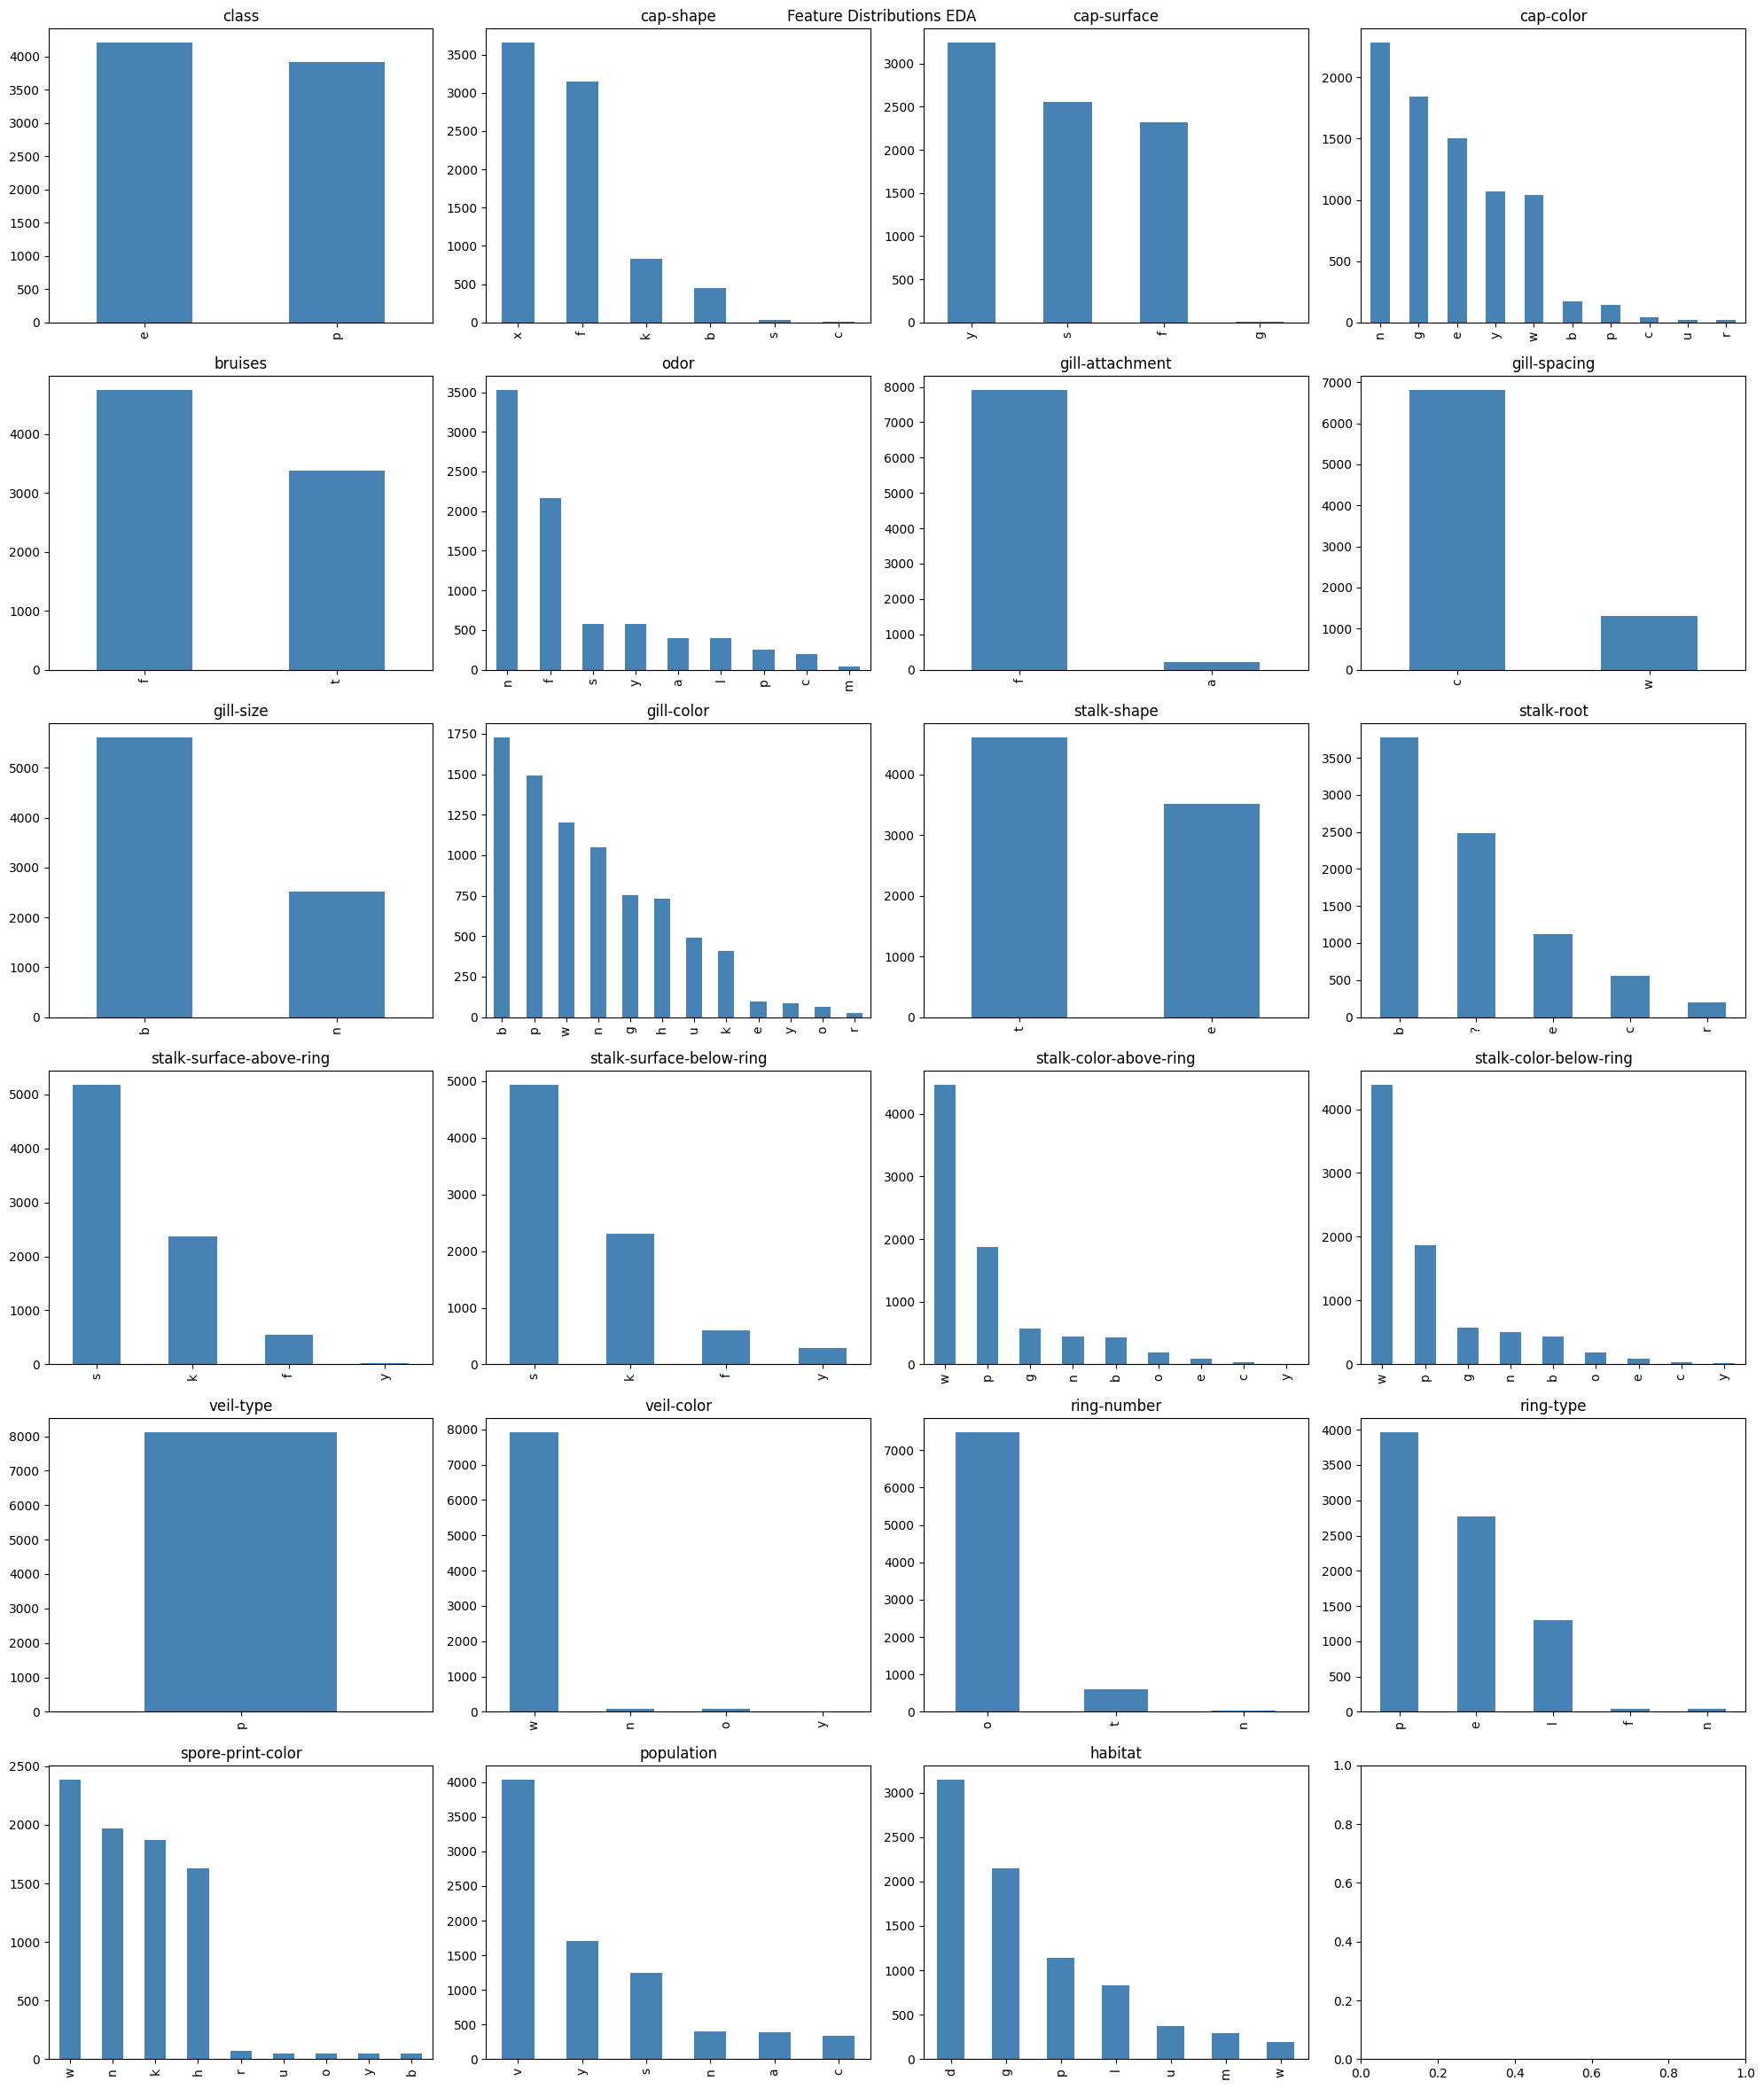

In [44]:
# check class balance
n_cols = 4
n_rows = math.ceil(len(df.columns) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, n_rows * 4))
axes = axes.flatten()

for i, col in enumerate(df.columns):
    df[col].value_counts().plot(kind='bar', ax=axes[i], color='steelblue')
    axes[i].set_title(col)
    axes[i].set_xlabel('')


plt.suptitle('Feature Distributions EDA')
plt.tight_layout()
plt.show()

In [45]:
# lof

lof = LocalOutlierFactor(n_neighbors=20)
labels = lof.fit_predict(df_encoded)

n_outliers = (labels == -1).sum()

print(f'Outliers: {n_outliers}, percent: {n_outliers/len(df)*100:.2f}%')
# there are only 6 outliers lol

df_no_outliers = df_encoded[labels == 1].reset_index(drop=True)

print(f'With outliers: {len(df_encoded)}')
print(f'No outliers: {len(df_no_outliers)}')


Outliers: 6, percent: 0.07%
With outliers: 8124
No outliers: 8118


## D Decision Tree

In [46]:

dt = DecisionTreeClassifier(
    max_depth=None,
    random_state=42,
    criterion='gini'
)

# E Feature Engineering

In [47]:

# decode
df_fe = df_no_outliers.copy()
for col in df_fe.columns:
    df_fe[col] = encoders[col].inverse_transform(df_fe[col].astype(int))

# population and habitat
df_fe['pop_habitat'] = df_fe['population'] + '_' + df_fe['habitat']

odor_map = {
    'a' :'o',
    'l' : 'o',
    'c' : 'o',
    'y' : 'o',
    'f' : 'o',
    'm' : 'o',
    'p' : 'o',
    's' : 'o',
    'n' : 'n'
}

df_fe["odorous"] = df_fe["odor"].map(odor_map)

## F Empirical Study

In [48]:
df_fe_outliers = df_encoded.copy()
for col in df_fe_outliers.columns:
    df_fe_outliers[col] = encoders[col].inverse_transform(df_fe_outliers[col].astype(int))

df_fe_outliers['pop_habitat'] = df_fe_outliers['population'] + '_' + df_fe_outliers['habitat']
df_fe_outliers['odorous'] = df_fe_outliers['odor'].map(odor_map)

for df_temp in [df_fe, df_fe_outliers]:
    for col in df_temp.columns:
        le = LabelEncoder()
        df_temp[col] = le.fit_transform(df_temp[col].astype(str))

In [61]:

configs = {
    'baseline': df_encoded,
    'no out, no fe': df_no_outliers,
    'out, fe' : df_fe_outliers,
    'no out, fe': df_fe
}

results = {}


for name, df_config in configs.items():
    X = df_config.drop(columns = ['class'])
    y = df_config['class']

    X_train_val, X_test, y_train_val, y_test = train_test_split(X, y, test_size=0.15, stratify=y, random_state=42)

    dt = DecisionTreeClassifier(criterion='gini', max_depth=5, random_state=42)
    print('with in built cross_val_score function')

    scores = cross_val_score(dt, X_train_val, y_train_val, cv=4, scoring = 'f1')

    results[name] = (scores, X_train_val, X_test, y_train_val, y_test)

    print(f'Name: {name} | F1 Mean {scores.mean() * 100:.2f}')

    print('with curstom kfold function')

    kfold(dt, X_train_val, y_train_val)

    print()
    print()




    

with in built cross_val_score function
Name: baseline | F1 Mean 97.63
with curstom kfold function
Mean F1: 97.79


with in built cross_val_score function
Name: no out, no fe | F1 Mean 97.69
with curstom kfold function
Mean F1: 97.81


with in built cross_val_score function
Name: out, fe | F1 Mean 99.68
with curstom kfold function
Mean F1: 99.71


with in built cross_val_score function
Name: no out, fe | F1 Mean 99.79
with curstom kfold function
Mean F1: 99.97




In [59]:
param_configs = {
    'gini, no lim' : DecisionTreeClassifier(criterion='gini', max_depth=None, random_state=42),
    'gini, md=5': DecisionTreeClassifier(criterion='gini', max_depth=5, random_state=42),
    'gini, md=10': DecisionTreeClassifier(criterion='gini', max_depth=10, random_state=42),
    'gini, md=20, min=5': DecisionTreeClassifier(criterion='gini', max_depth=20, min_samples_split=5, random_state=42),
    'gini, md=50': DecisionTreeClassifier(criterion='gini', max_depth=50, random_state=42),
    'entropy, no lim': DecisionTreeClassifier(criterion='entropy', max_depth=None, random_state=42),
    'entropy, md=10': DecisionTreeClassifier(criterion='entropy', max_depth=10, random_state=42),

}

X = df_fe.drop(columns = ['class'])
y = df_fe['class']

X_train_val, X_test, y_train_val, y_test = train_test_split(X, y, test_size=0.15, stratify=y, random_state=42)

for name, dt_configs in param_configs.items():
    print('with in built cross_val_score function')
    scores = cross_val_score(dt_configs, X_train_val, y_train_val, cv=4, scoring='f1')
    print(f'Name: {name} | F1 Mean {scores.mean() * 100:.2f}')
    print('with curstom kfold function')
    kfold(dt, X_train_val, y_train_val)

    print()
    print()

with in built cross_val_score function
Name: gini, no lim | F1 Mean 100.00
with curstom kfold function
Mean F1: 99.97


with in built cross_val_score function
Name: gini, md=5 | F1 Mean 99.79
with curstom kfold function
Mean F1: 99.97


with in built cross_val_score function
Name: gini, md=10 | F1 Mean 100.00
with curstom kfold function
Mean F1: 99.97


with in built cross_val_score function
Name: gini, md=20, min=5 | F1 Mean 100.00
with curstom kfold function
Mean F1: 99.97


with in built cross_val_score function
Name: gini, md=50 | F1 Mean 100.00
with curstom kfold function
Mean F1: 99.97


with in built cross_val_score function
Name: entropy, no lim | F1 Mean 100.00
with curstom kfold function
Mean F1: 99.97


with in built cross_val_score function
Name: entropy, md=10 | F1 Mean 100.00
with curstom kfold function
Mean F1: 99.97




In [51]:

X = df_fe.drop(columns = ['class'])
y = df_fe['class']

X_train_val, X_test, y_train_val, y_test = train_test_split(X, y, test_size=0.15, stratify=y, random_state=42)

best_dt = DecisionTreeClassifier(
    max_depth=None,
    random_state=42,
    criterion='gini'
)
best_dt.fit(X_train_val, y_train_val)

# eval
y_pred = best_dt.predict(X_test)

print(classification_report(y_test, y_pred, target_names=['edible', 'poisonous']))

              precision    recall  f1-score   support

      edible       1.00      1.00      1.00       631
   poisonous       1.00      1.00      1.00       587

    accuracy                           1.00      1218
   macro avg       1.00      1.00      1.00      1218
weighted avg       1.00      1.00      1.00      1218



## G Result Analysis

The feature engineering did lead to improved results. The baseline model performed the worst with a mean f1 score of 97.63%. With outliers removed it achieved 97.64%; with feature engineering 99.68% and with outliers removed and feature engineering 99.74%. This shows that feature engineering has a positive impact on the the data set, though it is minimal as the model already performs well. Outlier removal also had an impact but it was very small which is most likely due to the fact that only 6 outliers were detected and removed. During parameter tuning, nearly all models achieved a mean f1 of 100% except for the gini model with a depth of 5 which achieved 99.74%. For this reason the final best model chosen was the gini model with max_depth set to None. The model generalizes well, in the final test data an f1 score of 100% was achieved. The exceptional performance of the model is most likely due to the dataset being very good for classification tasks.

It should be noted that the above is when using the in built cross_val_score function which takes a combined set of the training and validation data and performs the split internally. When using a custom function that splits the train_val set into seperate data sets and performs kfold manually the model ranking remains the same however the greatest mean f1 achieved is 99.84% instead of 99.74%. Additionally, the effect of parameter tuning is the same however Mean f1 drops from 100% to 99.84%.

# References:

Risdal, M., & UCI Machine Learning. (2017). Mushroom Classification. Www.kaggle.com. https://www.kaggle.com/datasets/uciml/mushroom-classification

Waskom, M. (2012). seaborn: statistical data visualization — seaborn 0.10.1 documentation. Seaborn.pydata.org. https://seaborn.pydata.org/index.html